# Modified Code for VAE processing of ROOT data


**Installs**

In [1]:
# %pip install uproot

In [2]:
# %pip install awkward_pandas

In [3]:
import os
import numpy as np
import pandas as pd
import uproot

import matplotlib.pyplot as plt

In [4]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
%pip install --upgrade pip

  Using cached pip-26.2.1-py3-none-any.whl.metadata (4.6 kB)
Using cached pip-26.2.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 25.3
    Uninstalling pip-25.3:
      Successfully uninstalled pip-25.3
Note: you may need to restart the kernel to use updated packages.


In [5]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [6]:
import tensorflow 

In [7]:
##importing libraries##
import os
import numpy as np
import pandas as pd
import uproot

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

import time

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


Loading Root File

In [11]:


ROOT_FILE = "/Users/ruthhodgson/geant4_apps/QEPET/build/out.root"

file = uproot.open(ROOT_FILE)

print(file.keys())
tree = file['ThreeG_NCS']

# for key in file.keys():
#     print(file[key].keys())
print(tree.keys())


['TwoG_NCS;1', 'TwoG_PhantomSCS;1', 'TwoG_ScannerSCS;1', 'TwoG_PhantomSCS_ScannerSCS;1', 'TwoG_PhantomDCS;1', 'TwoG_ScannerDCS;1', 'TwoG_PhantomSCS_ScannerDCS;1', 'TwoG_PhantomDCS_ScannerSCS;1', 'TwoG_PhantomDCS_ScannerDCS;1', 'TwoG_MCS;1', 'TwoG_Excluded;1', 'ThreeG_NCS;1', 'ThreeG_ScannerSCS;1', 'ThreeG_ScannerDCS;1', 'ThreeG_ScannerTCS;1', 'ThreeG_MCS;1', 'ThreeG_Excluded;1', 'Run;1']
['EventID', 'NGammas', 'AnnihilX_mm', 'AnnihilY_mm', 'AnnihilZ_mm', 'GammaIndex', 'GammaTrackID', 'GammaParentID', 'HitIndex', 'VolumeID', 'VolumeName', 'ProcessID', 'ProcessName', 'EnergyDeposit_keV', 'PreEnergy_keV', 'PostEnergy_keV', 'X_mm', 'Y_mm', 'Z_mm', 'Theta_deg', 'Phi_deg', 'DeltaPhi01_deg', 'DeltaPhi02_deg', 'DeltaPhi12_deg']


Checking Branches and Channels

In [ ]:
branches  = [
    'EventID',
    'NGammas', 

    'AnnihilX_mm', 
    'AnnihilY_mm', 
    'AnnihilZ_mm', 
    
    'GammaIndex', 
    'GammaTrackID', 
    'GammaParentID', 
    
    'HitIndex', 
    
    'VolumeID', 
    'VolumeName', 
    'ProcessID', 
    'ProcessName', 
    
    'EnergyDeposit_keV', 
    'PreEnergy_keV', 
    'PostEnergy_keV', 
    
    'X_mm', 
    'Y_mm', 
    'Z_mm', 
    'Theta_deg',
    'Phi_deg', 
    'DeltaPhi01_deg', 
    'DeltaPhi02_deg', 
    'DeltaPhi12_deg']

tree = file["ThreeG_ScannerTCS"]
df = tree.arrays(branches, library="pd")

runs = ['NumberOfEvents, QuantumEntanglement']
run_tree = file['Run']
df_runs = run_tree.arrays(runs)
# print(df_runs)

print(df.head())
# print(df[['EnergyDeposit_keV', 'PreEnergy_keV']].head())

print(
    np.allclose(
        df["EnergyDeposit_keV"],
        df["PreEnergy_keV"]
    )
)

print(
    np.allclose(
        df["PostEnergy_keV"],
        0
    )
)

In [14]:
branches  = [
    'EventID',
    'NGammas', 

    'AnnihilX_mm', 
    'AnnihilY_mm', 
    'AnnihilZ_mm', 
    
    'GammaIndex', 
    'GammaTrackID', 
    'GammaParentID', 
    
    'HitIndex', 
    
    'VolumeID', 
    'VolumeName', 
    'ProcessID', 
    'ProcessName', 
    
    'EnergyDeposit_keV', 
    'PreEnergy_keV', 
    'PostEnergy_keV', 
    
    'X_mm', 
    'Y_mm', 
    'Z_mm', 
    'Theta_deg',
    'Phi_deg', 
    'DeltaPhi01_deg', 
    'DeltaPhi02_deg', 
    'DeltaPhi12_deg']

tree = file["ThreeG_NCS"]
df = tree.arrays(branches, library="pd")

print(df.head(3))
# print(df[['EnergyDeposit_keV', 'PreEnergy_keV']].head())


print(
    np.allclose(
        df["EnergyDeposit_keV"],
        df["PreEnergy_keV"]
    )
)

print(
    np.allclose(
        df["PostEnergy_keV"],
        0
    )
)

   EventID  NGammas  AnnihilX_mm  AnnihilY_mm  AnnihilZ_mm  GammaIndex  \
0        2        3    -0.293905     4.053828    -8.090448           0   
1        2        3    -0.293905     4.053828    -8.090448           1   
2        2        3    -0.293905     4.053828    -8.090448           2   

   GammaTrackID  GammaParentID  HitIndex  VolumeID  ...  PreEnergy_keV  \
0             4              1         0         1  ...     364.456299   
1             3              1         0         1  ...     227.327576   
2             2              1         0         1  ...     430.213928   

   PostEnergy_keV       X_mm       Y_mm       Z_mm  Theta_deg  Phi_deg  \
0             0.0  35.348804 -11.452375 -38.762901        NaN      NaN   
1             0.0  17.195129 -35.946274  32.120178        NaN      NaN   
2             0.0 -44.458641  39.904507   1.532497        NaN      NaN   

   DeltaPhi01_deg  DeltaPhi02_deg  DeltaPhi12_deg  
0             NaN             NaN             NaN  
1    

Checking Detector Hits and Number of Events

In [15]:
print()

print("Number of detector hits =", len(df))

print()

num = file['Run'].arrays('NumberOfEvents') 
print("Number of events =",
      num['NumberOfEvents'])

print()

print(df.describe())


Number of detector hits = 14172

Number of events = [100000]

            EventID  NGammas   AnnihilX_mm   AnnihilY_mm   AnnihilZ_mm  \
count  14172.000000  14172.0  14172.000000  14172.000000  14172.000000   
mean   49877.296994      3.0      1.876523      2.944788     -8.170338   
std    29037.733845      0.0      1.985492      2.564852      1.875388   
min        2.000000      3.0     -3.133895     -2.247797    -13.033757   
25%    24946.500000      3.0      0.319652      0.746678     -9.544018   
50%    49979.500000      3.0      1.898903      2.946253     -8.172962   
75%    75152.250000      3.0      3.433019      5.161663     -6.803274   
max    99856.000000      3.0      6.600159      8.146037     -3.156985   

         GammaIndex  GammaTrackID  GammaParentID  HitIndex  VolumeID  ...  \
count  14172.000000  14172.000000        14172.0   14172.0   14172.0  ...   
mean       1.000000      3.000000            1.0       0.0       1.0  ...   
std        0.816525      0.816525      

Defining Image Size

In [16]:
IMG_SIZE = 64

xmin = df.X_mm.min()
xmax = df.X_mm.max()

ymin = df.Y_mm.min()
ymax = df.Y_mm.max()

zmin = df.Z_mm.min()
zmax = df.Z_mm.max()

print(xmin, xmax)
print(ymin, ymax)
print(zmin, zmax)

-93.85215 96.86018
-98.20408 93.24706
-94.92272 91.91468


In [17]:
print(tree.num_entries)

14172.0


In [18]:
print(df.shape)
print(df["EventID"].nunique())
print(df.groupby(["VolumeID", "EventID"]).ngroups)

(14172, 24)
4724
4724


**Building Images for 2D Projections and Regresion Targets**



*   XY
*   XZ
*   YZ




In [19]:

images = []
targets = []

event_groups = df.groupby([ "VolumeID", "EventID"], sort=False)



print(f"Building images from {event_groups.ngroups} events...")


for i, ((vol_id, event_id), event) in enumerate(event_groups):

    # all hits with this VolumeID and EventID belong to one event

    image = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)


    # Channel 0: XY projection

    H_xy, _, _ = np.histogram2d(
        event["X_mm"],
        event["Y_mm"],
        bins=IMG_SIZE,
        range=[[xmin, xmax], [ymin, ymax]],
        weights=event["EnergyDeposit_keV"]
    )

    image[:, :, 0] = H_xy



    # Channel 1: XZ projection

    H_xz, _, _ = np.histogram2d(
        event["X_mm"],
        event["Z_mm"],
        bins=IMG_SIZE,
        range=[[xmin, xmax], [zmin, zmax]],
        weights=event["EnergyDeposit_keV"]
    )

    image[:, :, 1] = H_xz



    # Channel 2: YZ projection

    H_yz, _, _ = np.histogram2d(
        event["Y_mm"],
        event["Z_mm"],
        bins=IMG_SIZE,
        range=[[ymin, ymax], [zmin, zmax]],
        weights=event["EnergyDeposit_keV"]
    )

    image[:, :, 2] = H_yz

    # Regression Targets


    annihil_x = event["AnnihilX_mm"].iloc[0]
    annihil_y = event["AnnihilY_mm"].iloc[0]
    annihil_z = event["AnnihilZ_mm"].iloc[0]

    target = [
        annihil_x,
        annihil_y,
        annihil_z,
    ]



    # Store image and target


    images.append(image)
    targets.append(target)


    if (i + 1) % 1000 == 0:
        print(f"{i+1} events processed")


# Convert lists to arrays
images = np.array(images, dtype=np.float16)
targets = np.array(targets, dtype=np.float32)


print()
print("Images shape :", images.shape)
print("Targets shape:", targets.shape)

Building images from 4724 events...
1000 events processed
2000 events processed
3000 events processed
4000 events processed

Images shape : (4724, 64, 64, 3)
Targets shape: (4724, 3)


In [20]:
print("Images:", images.shape)
print("Targets:", targets.shape)

print("\nExample target:")
print(targets[0])

Images: (4724, 64, 64, 3)
Targets: (4724, 3)

Example target:
[-0.29390496  4.0538282  -8.090448  ]


In [21]:
images /= np.max(images)

print(images.min())
print(images.max())

0.0
1.0


In [22]:
print("Images shape:", images.shape)
print("Targets shape:", targets.shape)

print("\nFirst target:")
print(targets[0])

Images shape: (4724, 64, 64, 3)
Targets shape: (4724, 3)

First target:
[-0.29390496  4.0538282  -8.090448  ]


** Train-Test Split for Model**

In [23]:
from sklearn.model_selection import train_test_split

batch_size = 64

X_train, X_test, y_train, y_test = train_test_split(
    images,
    targets,
    test_size=0.2,
    random_state=42
)

train_dataset = (
    tf.data.Dataset.from_tensor_slices(X_train)
    .shuffle(len(X_train))
    .batch(batch_size)
)

test_dataset = (
    tf.data.Dataset.from_tensor_slices(X_test)
    .batch(batch_size)
)

print("X Training images:", X_train.shape)
print("X Testing images:", X_test.shape)

print("Y Training targets:", y_train.shape)
print("Y Testing targets:", y_test.shape)

X Training images: (3779, 64, 64, 3)
X Testing images: (945, 64, 64, 3)
Y Training targets: (3779, 3)
Y Testing targets: (945, 3)


**Standard Scaler**

In [24]:
from sklearn.preprocessing import StandardScaler


target_scaler = StandardScaler()


y_train_scaled = target_scaler.fit_transform(y_train)

y_test_scaled = target_scaler.transform(y_test)

print(y_train_scaled[0])

[ 1.5224975  -1.2996156  -0.78591067]


**VAE Model Building - ConVAE**

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Flatten,
    Dense,
    Dropout
)
class ConVAE(tf.keras.Model):

    def __init__(self, latent_dim):
        super(ConVAE, self).__init__()
        self.latent_dim = latent_dim
        self.encoder = tf.keras.Sequential(
            [
                tf.keras.layers.InputLayer(input_shape = (64, 64, 3)), 
                tf.keras.layers.Conv2D(filters = 32, kernel_size=3, strides = (2,2), activation = 'relu'),
                tf.keras.layers.Conv2D(filters = 64, kernel_size=3, strides = (2,2), activation = 'relu'),
                tf.keras.layers.Flatten(), #this layer doens't have an activation
                tf.keras.layers.Dense(latent_dim + latent_dim) # 2x as we have two params per dim
            ]
        )

        self.decoder = tf.keras.Sequential(
            [
                tf.keras.layers.InputLayer(input_shape = (latent_dim,)),#the latent dims are decided by us, this is the output of the encoder and so the input of the decoder
                tf.keras.layers.Dense(units = 16*16*64, activation = 'relu'),
                tf.keras.layers.Reshape(target_shape=(16,16,64)),
                tf.keras.layers.Conv2DTranspose(filters = 64, kernel_size = 3, strides=2, padding = 'same', activation = 'relu'),
                tf.keras.layers.Conv2DTranspose(filters = 32, kernel_size = 3, strides=2, padding = 'same', activation = 'relu'),
                tf.keras.layers.Conv2DTranspose(filters = 3, kernel_size = 3, strides = 1, padding='same'),
            ]
        )
    @tf.function
    def sample(self,eps=None):#eps is the radom noise
        if eps is None:
            eps = tf.random.normal(shape = (100, self.latent_dim))
        return self.decode(eps, apply_sigmoid = True)
    
    def encode(self, image):
        mean, logvar = tf.split(self.encoder(image), num_or_size_splits = 2, axis = 1)
        return mean, logvar

    def reparam(self, mean, logvar): #this returns z essentially from the mu, omega and epsilon
        eps = tf.random.normal(shape = mean.shape)
        return eps * tf.exp(logvar*0.5) + mean
    
    def decode(self, z, apply_sigmoid = False):
        logits = self.decoder(z)
        if apply_sigmoid:
            probs = tf.sigmoid(logits)
            return probs
        return logits
    



**Defining the Loss Function and Training function**

In [30]:
## loss function
learning_rate = 1e-4
optim = tf.keras.optimizers.Adam(learning_rate)

##define the logarithim of the pdf, here we use a normal dist

def log_pdf_norm(sample_z, mean, logvar, raxis = 1):
    log2pi = tf.math.log(2.*np.pi)
    return tf.reduce_sum(
        -0.5 * ((sample_z - mean)**2. * tf.exp(-logvar) + logvar + log2pi), axis = raxis
    )


def loss_func(model, image):
    image = tf.cast(image, tf.float32)
    mean, logvar = model.encode(image)
    z = model.reparam(mean, logvar)
    x_logit = model.decode(z)
    cross_ent = tf.nn.sigmoid_cross_entropy_with_logits(logits = x_logit, labels = image)
    log_p_im_z = -tf.reduce_sum(cross_ent, axis = [1,2,3])
    log_p_z = log_pdf_norm(z,0.,0.)
    log_q_z_im = log_pdf_norm(z, mean, logvar)
    
    return -tf.reduce_mean(log_p_im_z+log_p_z-log_q_z_im)

@tf.function
def training_vae(model, image, vae_optim):
    with tf.GradientTape() as tape:
        vae_loss = loss_func(model, image)
    vae_gradients = tape.gradient(vae_loss, model.trainable_variables)
    optim.apply_gradients(zip(vae_gradients, model.trainable_variables))




In [ ]:
# def visuals(model, epoch, test_sample):
#     mean, logvar = model.encode(test_sample)
#     # z = model.reparam(mean, logvar)
#     latents = model.sample(z)
    
#     fig = plt.figure(figsize = (4,4))

#     for i in range(latents.shape[0]):
#         plt.subplot(4,4,i+1)
#         plt.imshow(latents[i, :, :, 0],cmap=  'gray')
#         plt.axis('off')

#     plt.show()
#     plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))


**Running the VAE training to obtain our latent Z values**

In [31]:
epochs = 10
latent_dim = 4 #for now
num_examples = 8

random_vector = tf.random.normal(shape=[num_examples, latent_dim])

model = ConVAE(latent_dim)

for epoch in range(1, epochs + 1):
    start_t = time.time()
    for train_x in train_dataset:
        training_vae(model, train_x, optim)
    end_t = time.time()

    loss = tf.keras.metrics.Mean()
    for test_x in test_dataset:
        loss(loss_func(model, test_x))
    elbo = -loss.result()
    # clear_output(wait=False)
    print(f'Epoch: {epoch}, Test set ELBO: {elbo}, time elapse for current epoch: {end_t - start_t}')
    

    

Epoch: 1, Test set ELBO: -7289.052734375, time elapse for current epoch: 16.729640245437622
Epoch: 2, Test set ELBO: -637.4783935546875, time elapse for current epoch: 14.707255125045776
Epoch: 3, Test set ELBO: -317.5321044921875, time elapse for current epoch: 16.046332120895386
Epoch: 4, Test set ELBO: -193.3605194091797, time elapse for current epoch: 12.02339482307434
Epoch: 5, Test set ELBO: -148.47662353515625, time elapse for current epoch: 10.673936128616333
Epoch: 6, Test set ELBO: -114.60942840576172, time elapse for current epoch: 11.800364017486572
Epoch: 7, Test set ELBO: -93.70289611816406, time elapse for current epoch: 12.01445984840393
Epoch: 8, Test set ELBO: -81.90653991699219, time elapse for current epoch: 12.559960842132568
Epoch: 9, Test set ELBO: -73.79983520507812, time elapse for current epoch: 11.63949704170227
Epoch: 10, Test set ELBO: -69.62397766113281, time elapse for current epoch: 11.590878963470459


In [32]:
#checking shapes
print(X_train.shape)
print(y_train_scaled.shape)
print(type(X_train))
print(type(y_train_scaled))

(3779, 64, 64, 3)
(3779, 3)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


**Producing a predictor to obtain a predicted y from the latent space**

In [33]:
predict = tf.keras.Sequential(
        [tf.keras.layers.Input(shape=(latent_dim,)),
         tf.keras.layers.Dense(128, activation = 'relu'),
         tf.keras.layers.Dropout(0.3),
         tf.keras.layers.Dense(3)]
)
#obtain z from the vae to be used in the predictor training and train

target = tf.cast(target, tf.float32)
pred_optim = tf.keras.optimizers.Adam(learning_rate)

prediction_data = tf.data.Dataset.from_tensor_slices((X_train, y_train_scaled))
prediction_data = prediction_data.batch(batch_size)

@tf.function
def training_predict(predict, z, target, pred_optim):
    with tf.GradientTape() as tape:
        prediction = predict(z)
        pred_loss = tf.reduce_mean(tf.square(prediction-target))
    pred_grad =tape.gradient(pred_loss, predict.trainable_variables )
    pred_optim.apply_gradients(zip(pred_grad, predict.trainable_variables))
    return pred_loss





In [34]:
#running the predictor trainer

for epoch in range(1, epochs+1):
    loss_per_epoch = tf.keras.metrics.Mean()
    
    for image, target in prediction_data:
        mean, logvar = model.encode(image)
        z = mean

        pred_loss = training_predict(predict, z, target, pred_optim)
        

        loss_per_epoch.update_state(pred_loss)

    print(f"Epoch: {epoch}, Prediction loss: {loss_per_epoch.result().numpy():.6f}")



Epoch: 1, Prediction loss: 1.203094
Epoch: 2, Prediction loss: 1.023445
Epoch: 3, Prediction loss: 1.002246
Epoch: 4, Prediction loss: 1.001001
Epoch: 5, Prediction loss: 1.000948
Epoch: 6, Prediction loss: 1.000970
Epoch: 7, Prediction loss: 1.000992
Epoch: 8, Prediction loss: 1.001010
Epoch: 9, Prediction loss: 1.001026
Epoch: 10, Prediction loss: 1.001040


In [35]:
print("Target mean:", tf.reduce_mean(y_train_scaled, axis=0).numpy())
print("Target std:", tf.math.reduce_std(y_train_scaled, axis=0).numpy())

Target mean: [-8.8011092e-09 -5.8043157e-09 -2.4867077e-07]
Target std: [1.0000004  0.99999976 1.0000001 ]


In [36]:
print("Z shape:", z.shape)
print("Z std:", tf.math.reduce_std(z).numpy())

Z shape: (3, 4)
Z std: 2.942134


In [40]:
model.summary()

model.compile(
    optimizer="adam",
    loss='mse',
    metrics=["mae", 'accuracy']
)

Model: "con_vae_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 8)              │       134,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 64, 64, 3)      │       138,179 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 272,779 (1.04 MB)

 Trainable params: 272,779 (1.04 MB)

 Non-trainable params: 0 (0.00 B)

**Test Accuracy, loss and MAE**

In [41]:
prediction_test = tf.data.Dataset.from_tensor_slices((X_test, y_test_scaled))
prediction_test = prediction_test.batch(batch_size)

predicts = []
targets = []

for image, target in prediction_test:
    mean, logvar = model.encode(image)

    z = mean

    prediction = predict(z)

    predicts.append(prediction)
    targets.append(target)


In [42]:
print(prediction[:5].numpy())
print(target[:5].numpy())

[[-7.3680747e-04  1.5100087e-03  2.2451760e-02]
 [-2.3298021e-03  2.8108996e-03  2.2236947e-02]
 [-2.6394418e-03 -4.4668093e-05  2.1462832e-02]
 [-3.4566037e-03  3.0457962e-03  2.1486063e-02]
 [-2.2417204e-03 -3.9371806e-03  2.1931650e-02]]
[[ 0.18631557 -0.8893474  -0.12619363]
 [ 0.4756975   0.05254166 -1.9099288 ]
 [-0.04168591  1.0538514   0.425046  ]
 [ 1.867465   -0.03699524 -0.12217082]
 [-0.63506985 -1.3315121   1.2754341 ]]


In [43]:
predicts = tf.concat(predicts, axis = 0)
targets = tf.concat(targets, axis=0)

print(predicts.shape)

print(targets.shape)

test_mse = tf.reduce_mean(
    tf.square(prediction - target)
)

test_mae = tf.reduce_mean(
    tf.abs(prediction - target)
)

print("VAE Test MSE:", test_mse.numpy())
print("VAE Test MAE:", test_mae.numpy())

predicts_scaled = predicts.numpy()
final_preds = target_scaler.inverse_transform(predicts_scaled)


(945, 3)
(945, 3)
VAE Test MSE: 1.020616
VAE Test MAE: 0.8612001


In [44]:
for i in range(5):
    print("True:     ", y_test[i])
    print("Predicted:", final_preds[i])
    print()


True:      [  3.9668674   -0.14068586 -11.376202  ]
Predicted: [ 1.8513945  2.9346673 -8.127076 ]

True:      [ 2.7431226  6.9315124 -7.3705173]
Predicted: [ 1.8546711  2.9316103 -8.119777 ]

True:      [ 0.01365993 -1.55306    -6.5534334 ]
Predicted: [ 1.8478926  2.940583  -8.129065 ]

True:      [-1.0098882  0.9581149 -7.2366204]
Predicted: [ 1.8559242  2.931295  -8.124147 ]

True:      [ 0.9073846  -0.41132656 -6.617211  ]
Predicted: [ 1.8517714  2.9434218 -8.124912 ]



**Position Error**

In [45]:
position_error = final_preds[:,:3] - y_test[:,:3]


distance_error = np.sqrt(
    position_error[:,0]**2 +
    position_error[:,1]**2 +
    position_error[:,2]**2
)


print(
    "Mean annihilation position error:",
    np.mean(distance_error),
    "mm"
)

Mean annihilation position error: 3.6554356 mm


** Reconstruction for X,Y,Z Annihilation - True vs Predicted **

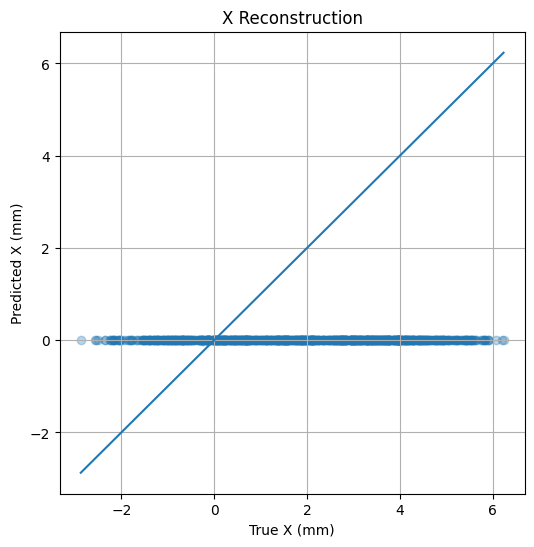

In [46]:
# X
plt.figure(figsize=(6,6))

plt.scatter(
    y_test[:,0],
    predicts[:,0],
    alpha=0.3
)

plt.xlabel("True X (mm)")
plt.ylabel("Predicted X (mm)")
plt.title("X Reconstruction")

plt.plot(
    [y_test[:,0].min(), y_test[:,0].max()],
    [y_test[:,0].min(), y_test[:,0].max()]
)

plt.grid()
plt.show()

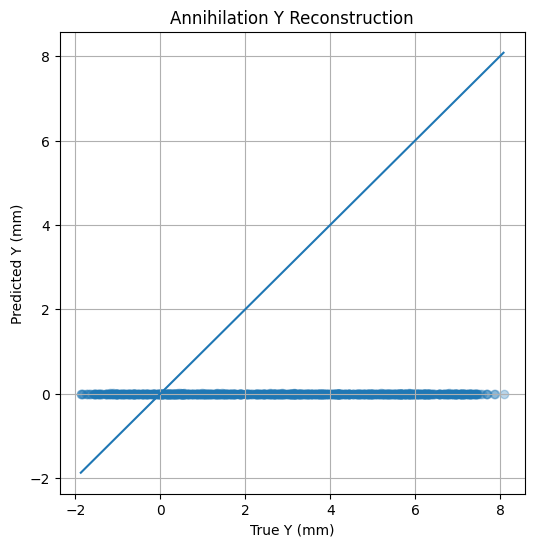

In [47]:
#Y
plt.figure(figsize=(6,6))

plt.scatter(
    y_test[:,1],          # True Y
    predicts[:,1],      # Predicted Y
    alpha=0.3
)

plt.xlabel("True Y (mm)")
plt.ylabel("Predicted Y (mm)")

plt.title("Annihilation Y Reconstruction")


plt.plot(
    [y_test[:,1].min(), y_test[:,1].max()],
    [y_test[:,1].min(), y_test[:,1].max()]
)

plt.grid()
plt.show()

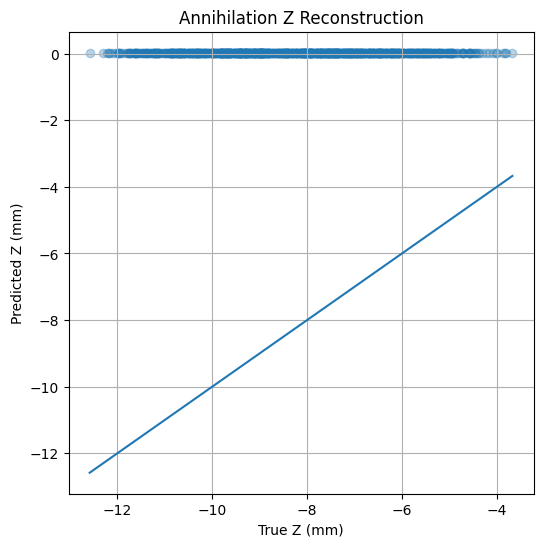

In [48]:
#Z
plt.figure(figsize=(6,6))

plt.scatter(
    y_test[:,2],          # True Z
    predicts[:,2],      # Predicted Z
    alpha=0.3
)

plt.xlabel("True Z (mm)")
plt.ylabel("Predicted Z (mm)")

plt.title("Annihilation Z Reconstruction")


plt.plot(
    [y_test[:,2].min(), y_test[:,2].max()],
    [y_test[:,2].min(), y_test[:,2].max()]
)

plt.grid()
plt.show()

**Comparing to a baseline that is just guessing in the 'middle' position**

In [49]:
# comparing to baseline
mean_position = np.mean(y_train, axis=0)

print(mean_position)
baseline_prediction = np.tile(
    mean_position,
    (len(y_test),1)
)

from sklearn.metrics import mean_squared_error

baseline_mse = mean_squared_error(
    y_test,
    baseline_prediction
)

vae_mse = mean_squared_error(
    y_test,
    predicts
)

print("Baseline MSE:", baseline_mse)
print("VAE+predictor MSE:", vae_mse)

[ 1.8564293  2.9337115 -8.166175 ]
Baseline MSE: 4.854374408721924
VAE+predictor MSE: 31.571306228637695


In [50]:
from sklearn.metrics import mean_absolute_error

baseline_mae = mean_absolute_error(
    y_test,
    baseline_prediction
)

vae_mae = mean_absolute_error(
    y_test,
    predicts
)

print("Baseline MAE:", baseline_mae)
print("vae+predictor MAE:", vae_mae)

Baseline MAE: 1.8638883829116821
vae+predictor MAE: 4.594785213470459


In [51]:
print("True X,Y,Z standard deviation:")
print(np.std(y_test, axis=0))

print("\nPredicted X,Y,Z standard deviation:")
print(np.std(predicts, axis=0))

True X,Y,Z standard deviation:
[2.0363991 2.6074986 1.8983053]

Predicted X,Y,Z standard deviation:
[0.00119789 0.00196035 0.00140531]


In [52]:
#comparing x,y,z separately
for i, coord in enumerate(["X","Y","Z"]):

    baseline = mean_absolute_error(
        y_test[:,i],
        baseline_prediction[:,i]
    )

    vae = mean_absolute_error(
        y_test[:,i],
        predicts[:,i]
    )

    print(coord)
    print("Baseline:", baseline)
    print("VAE:", vae)
    print()

X
Baseline: 1.7378349304199219
VAE: 2.337951183319092

Y
Baseline: 2.256887674331665
VAE: 3.237103223800659

Z
Baseline: 1.5969411134719849
VAE: 8.209303855895996



In [53]:
from sklearn.metrics import r2_score

print("Overall R²:", r2_score(y_test, predicts))

print("X R²:", r2_score(y_test[:,0], predicts[:,0]))
print("Y R²:", r2_score(y_test[:,1], predicts[:,1]))
print("Z R²:", r2_score(y_test[:,2], predicts[:,2]))

Overall R²: -6.9803338050842285
X R²: -0.9252429008483887
Y R²: -1.3141701221466064
Z R²: -18.701580047607422


**Plotting True and Predicted X,YZ co-ords**

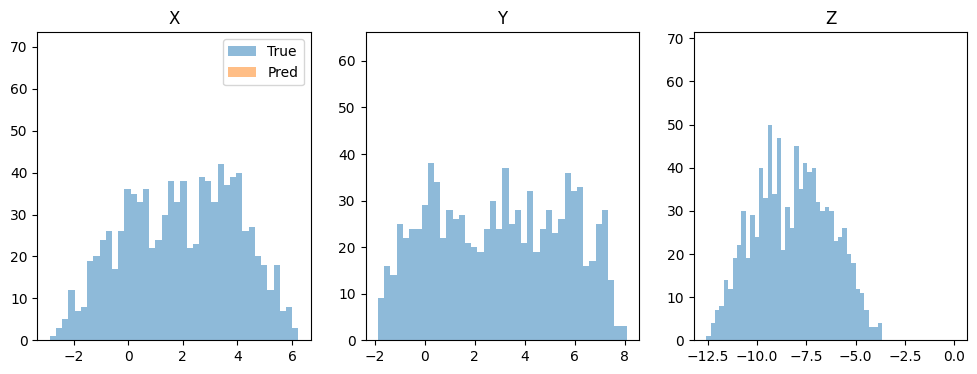

In [54]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.hist(y_test[:,0], bins=40, alpha=0.5, label="True")
plt.hist(predicts[:,0], bins=40, alpha=0.5, label="Pred")
plt.title("X")

plt.legend()

plt.subplot(1,3,2)
plt.hist(y_test[:,1], bins=40, alpha=0.5)
plt.hist(predicts[:,1], bins=40, alpha=0.5)
plt.title("Y")

plt.subplot(1,3,3)
plt.hist(y_test[:,2], bins=40, alpha=0.5)
plt.hist(predicts[:,2], bins=40, alpha=0.5)
plt.title("Z")

plt.show()

**Plotting Residuals - Difference between CNN model and True Annihilation Positions**

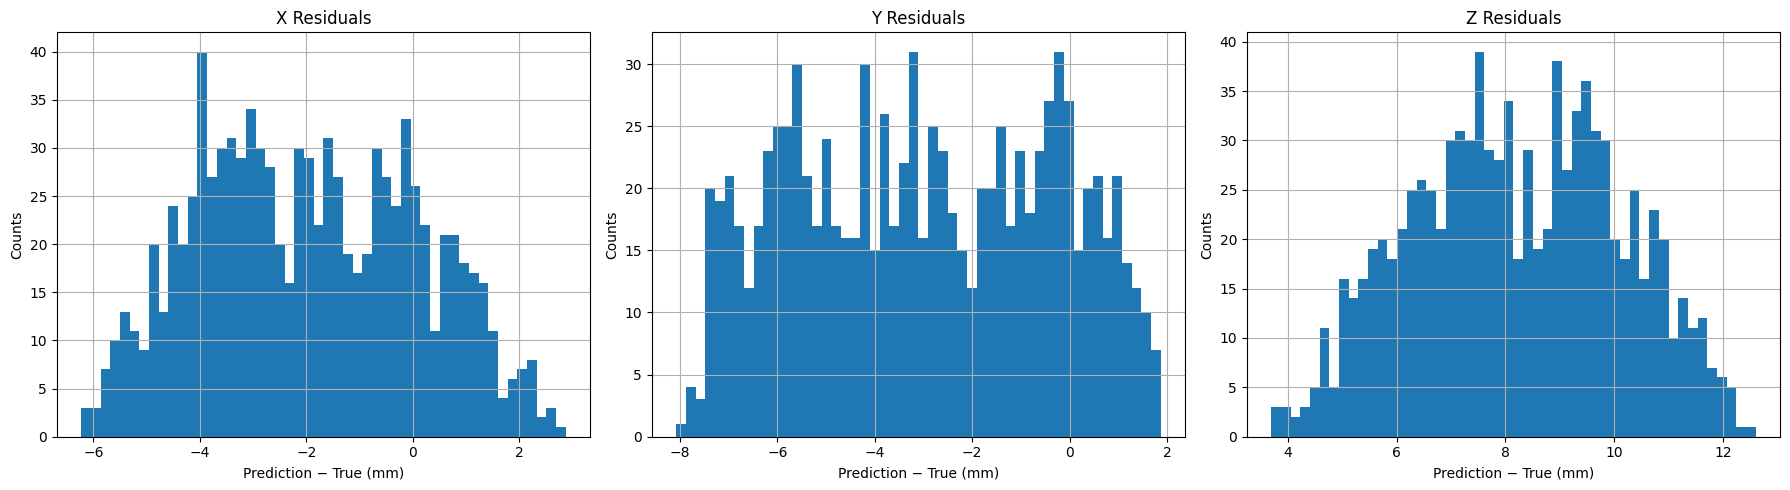

In [55]:
residuals = predicts - y_test
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

coords = ["X", "Y", "Z"]

for i, ax in enumerate(axes):

    ax.hist(
        residuals[:, i],
        bins=50
    )

    ax.set_title(f"{coords[i]} Residuals")
    ax.set_xlabel("Prediction − True (mm)")
    ax.set_ylabel("Counts")
    ax.grid(True)

plt.tight_layout()
plt.show()


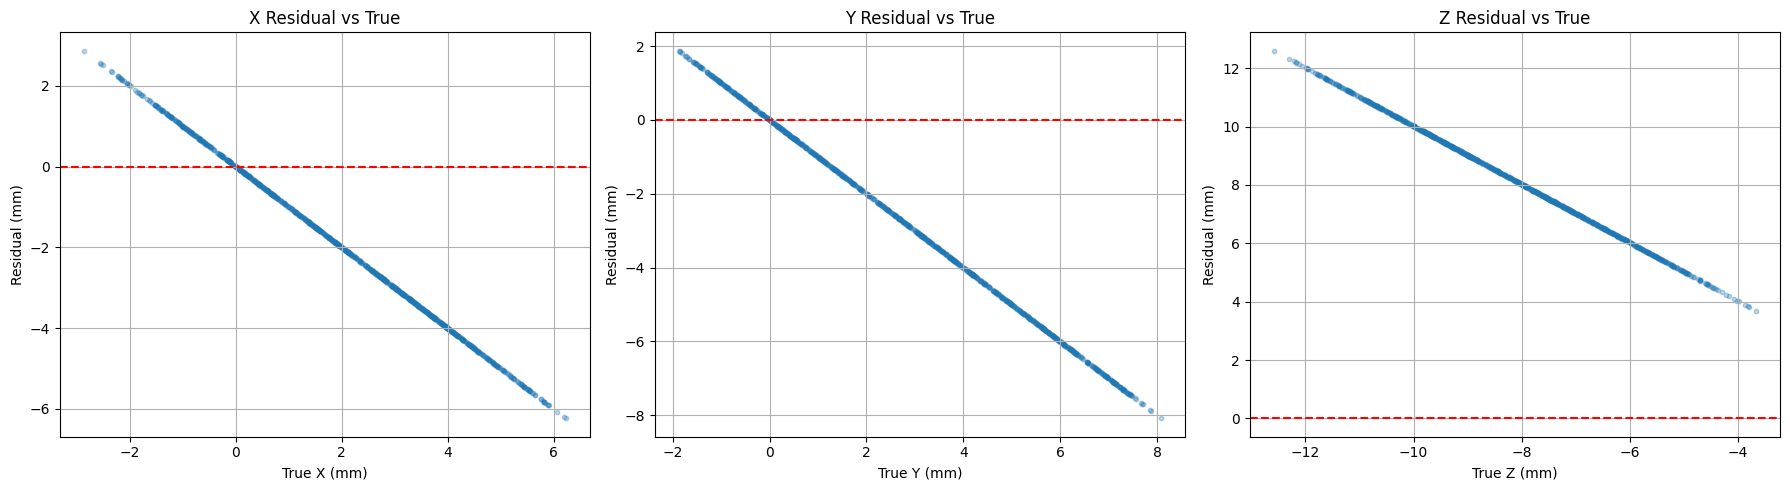

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

coords = ["X", "Y", "Z"]

for i, ax in enumerate(axes):

    ax.scatter(
        y_test[:, i],
        residuals[:, i],
        alpha=0.3,
        s=10
    )

    ax.axhline(
        0,
        color="red",
        linestyle="--"
    )

    ax.set_xlabel(f"True {coords[i]} (mm)")
    ax.set_ylabel("Residual (mm)")
    ax.set_title(f"{coords[i]} Residual vs True")
    ax.grid(True)

plt.tight_layout()
plt.show()

In [57]:
coords = ["X", "Y", "Z"]

for i in range(3):

    print(f"{coords[i]}")

    print(f"Mean residual: {np.mean(residuals[:,i]):.2f} mm")
    print(f"Std residual : {np.std(residuals[:,i]):.2f} mm")
    print(f"MAE          : {np.mean(np.abs(residuals[:,i])):.2f} mm")

    print()

X
Mean residual: -1.96 mm
Std residual : 2.04 mm
MAE          : 2.34 mm

Y
Mean residual: -2.99 mm
Std residual : 2.61 mm
MAE          : 3.24 mm

Z
Mean residual: 8.21 mm
Std residual : 1.90 mm
MAE          : 8.21 mm

